# Multiple Instance Learning for Histopathology: An Introduction to torchmil

**Author:** Francisco Miguel Castro Macías (see my webpage [here](https://franblueee.github.io/); contact me at [francastro8b@gmail.com](mailto:francastro8b@gmail.com)).

**Summary:** In this tutorial, we will learn how to use the [torchmil](https://torchmil.readthedocs.io/en/main/) library to train a Multiple Instance Learning (MIL) model to detect breast cancer metastases from Whole Slide Images (WSIs). We will use the CAMELYON16 dataset, which is a widely used benchmark for this task. We will prepare the data using the [TRIDENT](https://github.com/mahmoodlab/TRIDENT) library. Then, we will train a simple attention-based MIL model and evaluate its performance. Finally, we will visualize the results and localize the metastases in the WSIs.

**Presentation and code:** You can find the presentation associated with this tutorial [here](https://franblueee.github.io/assets/pdf/slides/2026_rise_miccai.pdf). The code for this tutorial is available in [this GitHub repository](https://github.com/Franblueee/rise-miccai-tutorial).

**Environment:** It is recommended to create two separate conda environments for this tutorial. One for the patch extraction process using TRIDENT and another one for training the MIL model using torchmil. The following commands will create both environments and install the necessary dependencies.

```bash
# TRIDENT environment
conda create -n trident python=3.10 -y
conda activate trident
cd some_directory_where_you_want_to_clone_trident
git clone https://github.com/mahmoodlab/trident.git
cd trident
pip install -e .

# torchmil environment
conda create -n torchmil python=3.11 -y
conda activate torchmil
pip install torchmil openslide-bin openslide-python opencv-python scikit-learn matplotlib
```


**Data:** You will need to download the original CAMELYON16 dataset from [here](https://camelyon16.grand-challenge.org/).

Let's start by importing the necessary libraries, setting up the device for training, and defining the paths to the data.

In [1]:
import os
import h5py
import openslide
import cv2
import torch
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm import tqdm

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "7"

TRIDENT_DIR = "/home/fran/data/datasets/CAMELYON16/trident_processed/20x_512px_0px_overlap/" # Path to the directory where TRIDENT will save the extracted patches and their corresponding feature vectors.
TIFF_DIR = "/data/datasets/CAMELYON16/original/images/" # Path to the directory where the original WSIs in TIFF format are stored.

## 1. Preparing and Understanding The Data

**Whole Slide Images (WSIs).** We will be working with Whole Slide Images (WSIs). These are gigapixel-sized images that are used in digital pathology. They are typically obtained by scanning glass slides that contain tissue samples. WSIs are used for various applications, including cancer diagnosis, prognosis, and research. They are typically stored in a multi-resolution format, which allows for efficient storage and retrieval of different levels of detail. We will be working with the CAMELYON16 dataset, which contains WSIs of lymph node sections from breast cancer patients. The WSIs in the CAMELYON16 dataset are stored in the `.tif` format.

<p align="center">
  <img src="img/wsi_weak_supervision.jpg" alt="Whole Slide Image (WSI) processing." width="700">
</p>

**Segmentation and patch extraction.** Due to the large size of WSIs, it is not feasible to process them directly with deep learning models. Instead, we need to segment the tissue regions and extract smaller patches from these regions. This process is known as patch extraction. [TRIDENT](https://github.com/mahmoodlab/TRIDENT) is arguably the most popular tool to accomplish this. I recommend taking a look at the TRIDENT repository for more details on how to use it. 

The following commands will run the patch extraction process for all the WSIs in the `./wsis` directory and save the processed data in the `./trident_processed` directory. We will be using the [CONCH model]() as patch encoder (we will give more details on what a patch encoder is soon). The patches will be extracted at a magnification level of 20x and will have a size of $512 \times 512$ pixels (which is equivalent to a patch size of $1024 \times 1.024$ at 10x magnification).

```bash
cd some_directory_where_you_cloned_trident
python run_batch_of_slides.py --task all --wsi_dir /data/datasets/CAMELYON16/original --job_dir /data/datasets/CAMELYON16/trident_processed  --patch_encoder conch_v15 --mag 20 --patch_size 512
```

This command will create the following directory structure in the `./trident_processed` directory:

```
trident_processed/
└── 20x_512px_0px_overlap/
    ├── features_conch_v15/
    |   ├──wsi1.h5
    |   ├──wsi2.h5
    |   └──...
    └── patches/
       ├──wsi1_patches.h5
       ├──wsi2_patches.h5
       └──...
```
The `features_conch_v15` directory contains the feature vectors for each patch, which are obtained by passing the patches through the CONCH model. The `patches` directory contains the coordinates of each patch in the original WSI. We will use these coordinates to assign labels to each patch based on the tumor annotations provided in the CAMELYON16 dataset.

**Extracting patch labels.** The patch extraction process will give us the coordinates of each patch and its corresponding feature vector (obtained from the CONCH model). For CAMELYON16, we have annotations that indicate the tumor regions in each WSI. This means that we can assign a label to each patch based on whether it falls within a tumor region or not. Although these patch labels will not be used for training the MIL model, they can be useful for evaluating the performance of the model at the patch level (e.g., by computing patch-level accuracy, precision, recall, etc.).

<p align="center">
  <img src="img/panda_wsi_patches_labels.png" alt="WSI with patch labels." width="700">
</p>

To assign a label to each patch, we will check if the proportion of tumor pixels in the patch is greater than a certain threshold (e.g., 50%). If it is, we will assign a label of 1 (indicating that the patch is positive for tumor), otherwise we will assign a label of 0 (indicating that the patch is negative for tumor). We provide a script that accomplishes this:

```bash
python extract_labels_camelyon16.py \ 
    --csv_path /data/datasets/CAMELYON16/original/wsi_labels.csv \ 
    --masks_dir /data/datasets/CAMELYON16/original/masks \
    --coords_dir /home/fran/data/datasets/CAMELYON16/trident_processed/20x_512px_0px_overlap/patches \
    --save_dir /home/fran/data/datasets/CAMELYON16/trident_processed/20x_512px_0px_overlap/patch_labels/ \
    --patch_size 1024 --patch_level 0
```

This will create a new directory called `patch_labels` that contains a `.h5` file for each WSI with the labels for each patch.

At this point, we have prepared all the data that we need. Let's take a look at some of the patches that we have extracted from a WSI. For this, we read the region determined by the coordinates of each patch. 

Number of patches: 6130
First 5 patch coordinates:
[[ 3072 12288]
 [ 3072 13312]
 [ 3072 14336]
 [ 3072 15360]
 [ 3072 16384]]


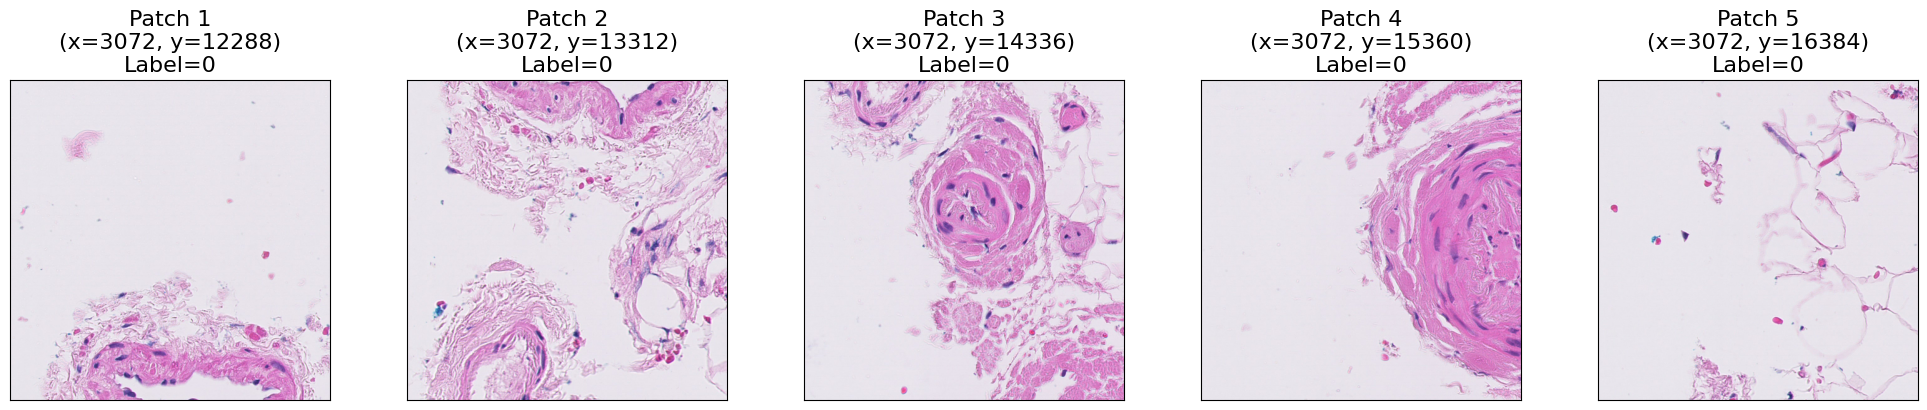

In [2]:
patch_size = 1024
coords_dir = TRIDENT_DIR + "patches/"
patch_labels_dir = TRIDENT_DIR + "patch_labels/"

wsi_name = "test_016"
# wsi_name = "tumor_005"

wsi_path = os.path.join(TIFF_DIR, wsi_name + ".tif")
slide = openslide.OpenSlide(wsi_path)

coords_path = os.path.join(coords_dir, wsi_name + "_patches.h5")
inst_coords = h5py.File(coords_path, "r")["coords"][:]

patch_labels_path = os.path.join(patch_labels_dir, wsi_name + ".h5")
patch_labels = h5py.File(patch_labels_path, "r")["patch_labels"][:]

print(f"Number of patches: {len(inst_coords)}")
print(f"First 5 patch coordinates:\n{inst_coords[:5]}")  

# show the first 5 patch coordinates on the WSI
fig, axs = plt.subplots(1, 5, figsize=(20, 4))
for i in range(5):
    x, y = inst_coords[i]
    patch_pil = slide.read_region((x, y), 0, (patch_size, patch_size))
    patch = np.array(patch_pil)[:, :, :3]
    patch = cv2.resize(patch, (512, 512))
    axs[i].imshow(patch)
    axs[i].set_xticks([])
    axs[i].set_yticks([])
    axs[i].set_title(f"Patch {i+1}\n(x={x}, y={y})\nLabel={patch_labels[i]}", fontsize=16)
plt.tight_layout()
plt.show()

As you can see, each patch contains a portion of the tissue. We can visualize the whole WSIs by placing each patch in its corresponding location in a blank canvas. Let's first read all the patches for the selected WSI. 

In [3]:
def read_wsi_patches(slide, inst_coords, patch_size=1024, resize_size=50):
    bag_len = len(inst_coords)
    patches_list = []
    row_list = []
    column_list = []
    for i in tqdm(range(bag_len), desc="Reading patches"):
        coord = inst_coords[i]
        x, y = coord

        patch_pil = slide.read_region((x, y), 0, (patch_size, patch_size))
        patch = np.array(patch_pil)[:, :, :3]
        patch = cv2.resize(patch, (resize_size, resize_size))
        patches_list.append(patch)

        row = int(y / patch_size)
        column = int(x / patch_size)
        row_list.append(row)
        column_list.append(column)

    row_array = np.array(row_list)
    column_array = np.array(column_list)

    row_array = row_array - row_array.min()
    column_array = column_array - column_array.min()

    return patches_list, row_array, column_array

patches_list, row_array, column_array = read_wsi_patches(
    slide, inst_coords, patch_size=1024, resize_size=50
)

Reading patches: 100%|██████████| 6130/6130 [02:46<00:00, 36.79it/s]


Now that we have the patches, we can visualize the WSI using the [`patches_to_canvas`](https://torchmil.readthedocs.io/en/main/api/visualize/vis_wsi/) function from the [`torchmil.visualize`](https://torchmil.readthedocs.io/en/main/api/visualize/) module. This function takes the list of patches and their corresponding coordinates and creates a canvas that represents the whole WSI. To visualize the labels of the patches, we use the [`draw_heatmap_wsi`](https://torchmil.readthedocs.io/en/main/api/visualize/vis_wsi/) function from the same module. This function takes the canvas, the patch labels, and the patch coordinates and draws a heatmap on top of the canvas, where red indicates positive patches and green indicates negative patches.

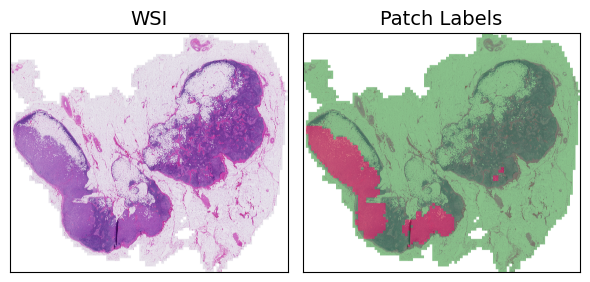

In [4]:
from torchmil.visualize import patches_to_canvas, draw_heatmap_wsi

canvas = patches_to_canvas(patches_list, row_array, column_array, 50)

canvas_with_patch_labels = draw_heatmap_wsi(
    canvas,
    patch_labels,
    50,
    row_array,
    column_array,
)

fig, axs = plt.subplots(1, 2, figsize=(6, 6))
axs[0].imshow(canvas)
axs[0].set_title("WSI", fontsize=14)
axs[1].imshow(canvas_with_patch_labels)
axs[1].set_title("Patch Labels", fontsize=14)
for ax in axs:
    ax.set_xticks([])
    ax.set_yticks([])
plt.tight_layout()
plt.show()

## 2. Creating the dataset

Let's now create a dataset to train our MIL models. For this, we will use the [`TridentWSIDataset`](https://torchmil.readthedocs.io/en/main/api/datasets/trident_wsi_dataset/) class from the [`torchmil.datasets`](https://torchmil.readthedocs.io/en/main/api/datasets/) module. This dataset class is designed to work with the data processed by TRIDENT and allows us to easily load the features and labels for each WSI. We will create a training set and a test set. The training set will contain 80% of the WSIs and the test set will contain the remaining 20%.

We provide two CSV files with the labels for each WSI in the training and test sets. Each CSV file has two columns: `wsi_name` and `wsi_label`. The `wsi_name` column contains the name of the WSI (without the `.tif` extension) and the `wsi_label` column contains the label for that WSI (0 for normal and 1 for tumor). You can modify these CSV files to create your own training and test sets. Just make sure that the `wsi_name` column matches the names of the WSIs in the `trident_processed` directory.


In [5]:
from torchmil.datasets import TridentWSIDataset
from sklearn.model_selection import train_test_split

patch_labels_path = TRIDENT_DIR + "patch_labels/"
feature_extractor = "conch_v15"

train_labels_path = "./train.csv"
train_wsis = pd.read_csv(train_labels_path)["wsi_name"].tolist()

test_labels_path = "./test.csv"
test_wsis = pd.read_csv(test_labels_path)["wsi_name"].tolist()

dataset = TridentWSIDataset(
    base_path=TRIDENT_DIR,
    labels_path=train_labels_path,
    feature_extractor=feature_extractor,
    patch_labels_path=patch_labels_path,
    wsi_names=train_wsis,
    bag_keys=["X", "Y", "y_inst", "adj", "coords"],
    patch_size=patch_size,
    load_at_init=True,
    wsi_name_col="wsi_name",
    wsi_label_col="wsi_label",
)

# Split the dataset into train and validation sets
bag_labels = dataset.get_bag_labels()
idx = list(range(len(bag_labels)))
val_prop = 0.2
idx_train, idx_val = train_test_split(
    idx, test_size=val_prop, random_state=1234, stratify=bag_labels
)
train_dataset = dataset.subset(idx_train)
val_dataset = dataset.subset(idx_val)

# Load the test dataset
test_dataset = TridentWSIDataset(
    base_path=TRIDENT_DIR,
    labels_path=test_labels_path,
    feature_extractor=feature_extractor,
    patch_labels_path=patch_labels_path,
    wsi_names=test_wsis,
    bag_keys=["X", "Y", "y_inst", "adj", "coords"],
    patch_size=patch_size,
    load_at_init=True,
    wsi_name_col="wsi_name",
    wsi_label_col="wsi_label",
)

# Print one bag
bag = train_dataset[0]
print("Bag type:", type(bag))
for key in bag.keys():
    print(key, bag[key].shape)

Loading bags: 100%|██████████| 128/128 [00:12<00:00, 10.26bag/s]

Bag type: <class 'tensordict._td.TensorDict'>
X torch.Size([6520, 768])
Y torch.Size([1])
y_inst torch.Size([6520])
adj torch.Size([6520, 6520])
coords torch.Size([6520, 2])


As you can see, in `torchmil` each bag is a `TensorDict`, and the different keys correspond to different elements of the bag. In this case, each bag has a feature matrix `X`, the bag label `Y`, the instance labels `y_inst`, the coordinates of the patches `coords` and an adjacency matrix `adj`. The adjacency matrix is used to define the spatial relationships between instances in the bag. Recall that the instance labels cannot be used during training, they are available only for evaluation purposes.

## 3. Mini-batching of bags

Tipically, the bags in a MIL dataset have different size. This can be a problem when creating mini-batches. To solve this, we use the function `collate_fn` from the [`torchmil.data`](../api/data/index.md) module. This function creates a mini-batch of bags by padding the bags with zeros to the size of the largest bag in the batch. The function also returns a mask tensor that indicates which instances are real and which are padding.

Let's create the dataloaders and visualize the shapes of a mini-batch. 

In [6]:
from torchmil.data import collate_fn

batch_size = 1

# Create dataloaders
train_dataloader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
)
val_dataloader = torch.utils.data.DataLoader(
    val_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
)
test_dataloader = torch.utils.data.DataLoader(
    test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn
)


it = iter(train_dataloader)
batch = next(it)
print("Batch type:", type(batch))
for key in batch.keys():
    print(key, batch[key].shape)

Batch type: <class 'tensordict._td.TensorDict'>
X torch.Size([1, 1358, 768])
Y torch.Size([1, 1])
y_inst torch.Size([1, 1358])
adj torch.Size([1, 1358, 1358])
coords torch.Size([1, 1358, 2])
mask torch.Size([1, 1358])


Each batch is again a `TensorDict` with an additional key `mask` that indicates which instances are real and which are padding. As we can see, the bags are padded to the maximum size of the bags in the batch with zeros. The mask tensor indicates which elements are real instances and which are padding. The function `collate_fn` also pads other tensors, such as the adjacency matrix or the instance coordinates. 

## 4. Training a model in CAMELYON16

We have shown how to load the CAMELYON16 dataset for the binary classification task. Now, let us train a MIL model in this dataset! 

For this example, we are going to implement the simple [ABMIL](https://arxiv.org/abs/1802.04712) model. ABMIL is already implemented in `torchmil`, (see [here](https://torchmil.readthedocs.io/en/main/api/models/abmil/)). However, for educational purposes, we will implement it from scratch. ABMIL is a simple attention-based MIL model that uses a single attention layer to aggregate the instance features into a bag representation. Despite its simplicity, ABMIL has been shown to achieve competitive performance in various MIL benchmarks, including CAMELYON16.

Recall how ABMIL was defined:

<p align="center">
  <img src="img/abmil.png" alt="ABMIL model." width="700">
</p>

\begin{aligned}
    \mathbf{h}_i & = \operatorname{NeuralNet}(\mathbf{x}_i) \\ 
    f_i & = \mathbf{w}^\top \tanh(\mathbf{h}_i \mathbf{V}) \\
    s_i & = \frac{\exp(f_i)}{\sum_{j} \exp(f_j)} \\
    \mathbf{z} &= \sum_{i} s_i \mathbf{h}_i \\
    \hat{Y} & = \operatorname{Classifier}(\mathbf{z})
\end{aligned}



In [2]:
class ABMIL(torch.nn.Module):

    def __init__(
        self,
        in_dim: int,
        att_dim: int = 128,
    ) -> None:
        super().__init__()
        
        self._in_dim = in_dim
        self._att_dim = att_dim

        self._fc1 = torch.nn.Linear(in_dim, att_dim)
        self._fc2 = torch.nn.Linear(att_dim, 1)

        self._classifier = torch.nn.Linear(in_dim, 1)

        self._criterion = torch.nn.BCEWithLogitsLoss()

    def forward(
        self, X: torch.Tensor, mask: torch.Tensor = None, return_att: bool = False
    ) -> tuple[torch.Tensor, torch.Tensor]:
        """
        Forward pass.

        Arguments:
            X: Bag features of shape `(batch_size, bag_size, in_dim)`.
            mask: Mask of shape `(batch_size, bag_size)`.
            return_att: If True, returns attention values (before normalization) in addition to `Y_pred`.

        Returns:
            Y_pred: Bag label logits of shape `(batch_size,)`.
            att: Only returned when `return_att=True`. Attention values (before normalization) of shape (batch_size, bag_size).
        """

        if mask is None:
            mask = torch.ones(X.shape[0], X.shape[1], dtype=torch.bool, device=X.device)

        H = self._fc1(X)  # (batch_size, bag_size, att_dim)
        H = torch.nn.functional.tanh(H) # (batch_size, bag_size, att_dim)
        f = self._fc2(H)  # (batch_size, bag_size, 1)

        f_masked = f.masked_fill(mask.unsqueeze(-1) == 0, float("-inf")) # (batch_size, bag_size, 1)

        s = torch.nn.functional.softmax(f_masked, dim=1) # (batch_size, bag_size, 1)

        z = torch.bmm(X.transpose(1, 2), s).squeeze(dim=-1)  # (batch_size, in_dim)

        Y_pred = self._classifier(z)  # (batch_size, 1)

        if return_att:
            return Y_pred, f
        else:
            return Y_pred

    def compute_loss(
            self, Y: torch.Tensor, X: torch.Tensor, mask: torch.Tensor = None
        ) -> tuple[torch.Tensor, dict]:
            """
            Compute loss given true bag labels.

            Arguments:
                Y: Bag labels of shape `(batch_size,)`.
                X: Bag features of shape `(batch_size, bag_size, in_dim)`.
                mask: Mask of shape `(batch_size, bag_size)`.

            Returns:
                Y_pred: Bag label logits of shape `(batch_size,)`.
                loss_dict: Dictionary containing the loss value.
            """

            Y_pred = self.forward(X, mask, return_att=False)

            crit_loss = self._criterion(Y_pred.float(), Y.float())
            crit_name = self._criterion.__class__.__name__

            return Y_pred, {crit_name: crit_loss}

We have implemented a method called `compute_loss` that computes the binary cross-entropy loss for a given batch of bags. We have done this so that we can train the model using the [`Trainer`](https://torchmil.readthedocs.io/en/main/api/utils/trainer/) class from `torchmil`. This class provides a generic training loop for any MIL model and allows us to easily log the losses and metrics during training. You can check the documentation of the `Trainer` class for more details on how to use it and the different parameters that it accepts.

For now, let us just keep it simple and perform a simple training using the `torch.optim.Adam` optimizer. When using the features from a foundation model, most of `torchmil` models obtain very good results in just a few epochs.

In [8]:
from torchmil.utils import Trainer
import torchmetrics

model = ABMIL(in_dim=768, att_dim=128)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

trainer = Trainer(
    model=model,
    optimizer=optimizer,
    metrics_dict={"acc": torchmetrics.Accuracy(task="binary").to(device)},
    obj_metric="acc",
    device=device,
    disable_pbar=False,
    verbose=False,
)

trainer.train(
    max_epochs=5, train_dataloader=train_dataloader, val_dataloader=val_dataloader
)

[Epoch 5] Validation : 100%|██████████| 54/54 [00:00<00:00, 152.26it/s, val/loss=0.0848, val/BCEWithLogitsLoss=0.0848, val/acc=0.981]


## 5. Evaluating the Model

Let's evaluate the model. We are going to compute the accuracy and f1-score on the test set. The accuracy is the proportion of correctly classified bags, while the f1-score is the harmonic mean of precision and recall. The f1-score is a good metric for imbalanced datasets.
Typically, in MIL datasets, there are more negative bags than positive bags.

In [9]:
from sklearn.metrics import accuracy_score, f1_score

inst_pred_list = []
y_inst_list = []
Y_pred_list = []
Y_list = []

model = model.to(device)
model.eval()

for batch in test_dataloader:
    batch = batch.to(device)

    X = batch["X"].to(device)
    mask = batch["mask"].to(device)
    adj = batch["adj"].to(device)
    Y = batch["Y"]

    # predict bag label using our model
    out = model(X, mask)
    Y_pred = (out > 0).float()

    Y_pred_list.append(Y_pred)
    Y_list.append(Y)

Y_pred = torch.cat(Y_pred_list).cpu().numpy()
Y = torch.cat(Y_list).cpu().numpy()

print(f"test/bag/acc: {accuracy_score(Y_pred, Y)}")
print(f"test/bag/f1: {f1_score(Y_pred, Y)}")

test/bag/acc: 0.953125
test/bag/f1: 0.9375


Excellent! Our model has reached a very high accuracy and f1-score in only 5 epochs! This shows how simple is to obtain very good results in one of the most famous WSI classification datasets.

## 6. Localizing the Metastases

Now that we have trained a model, we can use it to localize the metastases in the WSI. We will use the attention scores of the instances to localize the metastases. The attention scores indicate the importance of each instance for the bag-level prediction. Patches with high attention scores are more likely to contain tumor tissue, while patches with low attention scores are more likely to contain normal tissue.

Let's choose the same WSI that we visualized at the beginning of the tutorial and compute the attention scores for each patch.

In [ ]:
wsi_name = "test_016"
bag = test_dataset._build_bag(wsi_name)

X = bag["X"].unsqueeze(0).to(device)
y_inst = bag["y_inst"].cpu().numpy()
Y_pred, y_inst_pred = model(X, return_att=True)

y_inst_pred = y_inst_pred.squeeze(0).detach().cpu().numpy()

Now, we visualize the attention scores as a heatmap on top of the WSI. As before, we use the function [`draw_heatmap_wsi`](https://torchmil.readthedocs.io/en/main/api/visualize/vis_wsi/) from the [`torchmil.visualize`](https://torchmil.readthedocs.io/en/main/api/visualize/) module. The heatmap shows the predicted scores for each instance, with red indicating high scores and green indicating low scores. You can also customize these colors. 

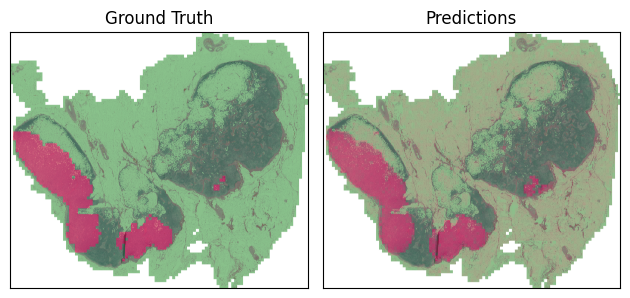

In [11]:
from torchmil.visualize import draw_heatmap_wsi

y_inst_pred = (y_inst_pred - y_inst_pred.min()) / (
    y_inst_pred.max() - y_inst_pred.min()
)

canvas_labels = draw_heatmap_wsi(
    canvas,
    y_inst,
    50,
    row_array,
    column_array,
)

canvas_pred = draw_heatmap_wsi(canvas, y_inst_pred, 50, row_array, column_array)

# plot canvas side by side

fig, ax = plt.subplots(1, 2)
ax[0].imshow(canvas_labels)
ax[0].set_title("Ground Truth")
ax[1].imshow(canvas_pred)
ax[1].set_title("Predictions")
for a in ax:
    a.set_xticks([])
    a.set_yticks([])
plt.tight_layout()
plt.show()

The heatmap shows the predicted scores for each instance, with red indicating high scores and green indicating low scores. Our model is able to detect the metastases in the WSI! Note that the model has learned to detect these regions without any instance-level labels, only using the bag-level labels. This is a clear example of the power of MIL in WSI classification tasks.